## Acceso a los ficheros de volcado de Reddit (Reddit Dump) para la realización de la práctica 2 de Procesamiento del Lenguaje Natural Escrito

Debido a las últimas limitaciones en la red Reddit para conseguir la API Key necesaria para su acceso, se ha decidido obtener la información a partir de un volcado de Reddit del año 2025 donde se han seleccionado un conjunto de subreddits con todos sus *submissions* y *comments*.

Estos volcados de Reddit se dividen en dos ficheros con formato ZST:
* El fichero RS_2025.zst contiene todas las *submissions* (hilos o posts) por los subreddits seleccionados junto con toda su información.
* El fichero RC_2025.zst tiene todos los *comments* por cada uno de las *submissions* de los subreddits seleccionados y que aparecen en RS_2025.zst.

Por otro lado, están los volcados de 2025 del subreddit "OpinionesPolemicas" para poder realizar un apartado de la práctica 2 con los siguientes ficheros:
* RS_OpinionesPolemicas2025.zst
* RC_OpinionesPolemicas2025.zst

## Estructura de los datos

### Submissions (RS_2025.zst)

Cada línea del fichero es un objeto JSON con los siguientes atributos principales:

| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único de la submission |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que creó la submission |
| `title` | Título del post o hilo|
| `selftext` | Contenido del post o hilo (si es de tipo texto) |
| `url` | Enlace asociado (si es de tipo link) |
| `score` | Puntuación (upvotes - downvotes) |
| `num_comments` | Número de comentarios |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `permalink` | Enlace permanente al post o hilo |
| `is_self` | `true` si es un post o hilo de texto, `false` si es un enlace |
| `over_18` | `true` si está marcado como contenido adulto |
| `edited` | Timestamp de edición o `false` si no fue editado |
| `stickied` | `true` si está fijado en el subreddit |
| `locked` | `true` si los comentarios están bloqueados |
| `spoiler` | `true` si contiene spoilers |
| `link_flair_text` | Etiqueta (flair) del post o hilo |

### Comments (RC_2025.zst)

Cada línea del fichero es un objeto JSON con los siguientes atributos principales:

| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único del comentario |
| `link_id` | ID de la submission a la que pertenece (formato `t3_xxxxx`) |
| `parent_id` | ID del elemento padre: `t3_xxxxx` si es respuesta directa al post, `t1_xxxxx` si es respuesta a otro comentario |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que escribió el comentario |
| `body` | Contenido del comentario |
| `score` | Puntuación (upvotes - downvotes) |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `is_submitter` | `true` si el autor es el mismo que creó la submission |
| `edited` | Timestamp de edición o `false` si no fue editado |
| `stickied` | `true` si está fijado |
| `controversiality` | `1` si el comentario es controvertido, `0` en caso contrario |
| `distinguished` | Indica rol especial (`moderator`, `admin`) o `null` |

## Relación entre ficheros

Para vincular comentarios con sus submissions, se usa el campo `link_id` de los comentarios, que corresponde al `id` de la submission con el prefijo `t3_`. Por ejemplo, un comentario con `link_id: "t3_abc123"` pertenece a la submission con `id: "abc123"`.

In [1]:
# Descargamos los dos ficheros desde el servidor para procesarlos.
#
# Ficheros:
#   - RS_2025.zst: Submissions (~9,2 GB) - Contiene los posts o hilos de los subreddits seleccionados
#   - RC_2025.zst: Comments (~55 GB) - Contiene todos los comentarios de dichas submissions
#   - RS_OpinionesPolemicas2025.zst: Submissions (~5,6 MB) - Contiene los posts o hilos del subreddit "OpinionesPolemicas"
#   - RC_OpinionesPolemicas2025.zst: Comments (~22,5 GB) - Contiene todos los comentarios de las submissions de "OpinionesPolemicas"

# !wget --no-check-certificate  https://valencia.inf.um.es/valencia-plne/RS_2025.zst
# !wget --no-check-certificate  https://valencia.inf.um.es/valencia-plne/RC_2025.zst

submissions_file = "RS_2025.zst"
comments_file = "RC_2025.zst"

# !wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RS_OpinionesPolemicas2025.zst
# !wget --no-check-certificate https://valencia.inf.um.es/valencia-plne/RC_OpinionesPolemicas2025.zst

# submissions_file = "RS_OpinionesPolemicas2025.zst"
# comments_file = "RC_OpinionesPolemicas2025.zst"


## Funciones para procesar los ficheros ZST

A continuación se definen las tres funciones principales para trabajar con los dumps de Reddit:

### `stream_zst_file(filepath)`
Generador que lee un fichero `.zst` línea por línea y devuelve cada objeto JSON. Utiliza descompresión en streaming para no cargar todo el fichero en memoria, lo cual es esencial dado el tamaño de los dumps.

### `extract_submissions(filepath, subreddit, n_submissions, min_comments)`
Extrae submissions de un subreddit específico, capturando todos los atributos disponibles en el dump. Parámetros:
- `filepath`: Ruta al fichero RS_2025.zst
- `subreddit`: Nombre del subreddit (sin el prefijo "r/")
- `n_submissions`: Número máximo de submissions a extraer (por defecto 3)
- `min_comments`: Filtra submissions con al menos este número de comentarios (por defecto 250)

Atributos más importantes que se obtendrán para los submissions:
| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único de la submission |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que creó la submission |
| `title` | Título del post o hilo|
| `selftext` | Contenido del post o hilo (si es de tipo texto) |
| `url` | Enlace asociado (si es de tipo link) |
| `score` | Puntuación (upvotes - downvotes) |
| `num_comments` | Número de comentarios |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `is_self` | `true` si es un post o hilo de texto, `false` si es un enlace |
| `link_flair_text` | Etiqueta (flair) del post o hilo |

Además de estos atributos, añade los campos calculados `name` (id con prefijo `t3_`), `created_datetime` (fecha en formato ISO 8601) y `comments` (lista vacía que se rellenará posteriormente).

### `extract_comments_for_submissions(filepath, submissions, num_comments)`
Busca los comentarios asociados a las submissions extraídas, capturando los atributos más importantes disponibles. Parámetros:
- `filepath`: Ruta al fichero RC_2025.zst
- `submissions`: Lista de submissions obtenida con la función anterior
- `num_comments`: Número máximo de comentarios a extraer por cada submission

Los atributos más importantes para los comentarios son los siguientes:
| Atributo | Descripción |
|----------|-------------|
| `id` | Identificador único del comentario |
| `link_id` | ID de la submission a la que pertenece (formato `t3_xxxxx`) |
| `parent_id` | ID del elemento padre: `t3_xxxxx` si es respuesta directa al post, `t1_xxxxx` si es respuesta a otro comentario |
| `subreddit` | Nombre del subreddit |
| `author` | Usuario que escribió el comentario |
| `body` | Contenido del comentario |
| `score` | Puntuación (upvotes - downvotes) |
| `created_utc` | Fecha de creación (timestamp Unix) |
| `is_submitter` | `true` si el autor es el mismo que creó la submission |

La función vincula cada comentario con su submission mediante el campo `link_id`, que contiene el `id` de la submission con el prefijo `t3_`. También añade los campos calculados `name` y `created_datetime`.

In [4]:
#!/usr/bin/env python3
"""
=====================
Este ejemplo procesa archivos de un volcado de Reddit en formato .zst para extraer
submissions y sus comentarios de un subreddit específico.
"""


import zstandard as zstd
import json
import argparse
import io
import sys
from pathlib import Path
from datetime import datetime, UTC
import random # Para hacer la distribucion en el tiempo


def stream_zst_file(filepath):
    """
    Genera objetos JSON línea por línea desde un archivo .zst
    """
    dctx = zstd.ZstdDecompressor(max_window_size=2**31)

    with open(filepath, 'rb') as fh:
        with dctx.stream_reader(fh) as reader:
            text_stream = io.TextIOWrapper(reader, encoding='utf-8', errors='ignore')

            for line in text_stream:
                line = line.strip()
                if not line:
                    continue
                try:
                    yield json.loads(line)
                except json.JSONDecodeError:
                    continue


def extract_submissions(filepath, subreddit, n_submissions=80, min_comments=250):
    """
    Extrae N submissions de un subreddit con al menos min_comments comentarios.
    Captura los atributos más importantes del dump.
    """
    submissions = []
    subreddit_lower = subreddit.lower()

    print(f"🔍 Buscando submissions en el subreddit {subreddit} con ≥ {min_comments} comentarios...")

    count = 0
    scanned = 0

    for obj in stream_zst_file(filepath):
        if obj.get('subreddit', '').lower() != subreddit_lower:
            continue

        scanned += 1
        num_comments = obj.get('num_comments', 0)

        if num_comments < min_comments:
            continue

        # Copiar los atributos más importantes
        submission = {
            "id": obj.get("id"),
            "subreddit": obj.get("subreddit"),
            "author": obj.get("author"),
            "title": obj.get("title"),
            "selftext": obj.get("selftext", ""),
            "url": obj.get("url", ""),
            "score": obj.get("score", 0),
            "num_comments": obj.get("num_comments", 0),
            "created_utc": obj.get("created_utc"),
            "is_self": obj.get("is_self", ""),
            "link_flair_text": obj.get("link_flair_text")
        }

        # Añadir campos calculados
        submission['name'] = f"t3_{obj.get('id')}"
        submission['created_datetime'] = datetime.fromtimestamp(
            obj.get('created_utc', 0), UTC
        ).isoformat() if obj.get('created_utc') else None
        submission['comments'] = []  # Se llenará después con los comentarios

        """
        Ahora hacemos la distribución en el tiempo.
        Cuando se ha llenado la lista con los N submissions se calcula un número al azar entre 0 y el número de hilos que llevamos procesados.
        Si este número está entre 0 y N-submissions se cambia el submission correspondiente a ese número por el nuevo.
        De esta forma nos aseguramos tener hilos de toda la distribución temporal.
        Si un subreddit tiene 100.000 hilos, cuando lleve procesados la mitad, count valdrá 50.000, y la probabilidad de que se añada ese
        hilo  será N-submissions/50.000. Esta lógica para extraer los hilos/comentarios a lo largo del tiempo se llama Reservoir Sampling
        """

        if count < n_submissions:
            submissions.append(submission)
        else:
            j = random.randint(0, count)
            if j < n_submissions:
                submissions[j] = submission

        count += 1

    print(f"\n  Escaneadas: {scanned} del subreddit")
    print(f"  Encontradas: {len(submissions)} con ≥{min_comments} comentarios\n")
    return submissions


def extract_comments_for_submissions(filepath, submissions, num_comments=50):
    """
    Extrae N comentarios para cada submission.
    Captura los atributos más importantes del dump.
    """
    if num_comments <= 0:
        print("⏭️  num_comments=0, saltando búsqueda de comentarios")
        return

    if not submissions:
        print("⏭️  Sin submissions")
        return

    submission_map = {
    subreddit: {s['name']: s for s in lista_hilos}
    for subreddit, lista_hilos in submissions.items()
    }
    comment_count = {
    subreddit: {s['name']: 0 for s in lista_hilos}
    for subreddit, lista_hilos in submissions.items()
}

    pending = set(name for subdiccionario in submission_map.values()for name in subdiccionario)

    print(f"🔍 Buscando hasta {num_comments} comentarios por submission...")

    total_comments = 0

    for obj in stream_zst_file(filepath):
        link_id = obj.get('link_id')
        if link_id not in pending:
            continue

        # Copiar los atributos más importantes

        comment = {
            "id": obj.get("id"),
            "link_id": obj.get("link_id"),
            "parent_id": obj.get("parent_id"),
            "subreddit": obj.get("subreddit"),
            "author": obj.get("author"),
            "body": obj.get("body", ""),
            "score": obj.get("score", 0),
            "created_utc": obj.get("created_utc"),
            "is_submitter": obj.get("is_submitter", False)
        }

        subreddit = obj.get("subreddit").lower()

        # Añadir campos calculados
        comment['name'] = f"t1_{obj.get('id')}"
        comment['created_datetime'] = datetime.fromtimestamp(
            obj.get('created_utc', 0), UTC
        ).isoformat() if obj.get('created_utc') else None

        # Hacemos la lógica Reservoir Sampling para obtener comentarios distribuidos en el tiempo
        current_comments_list = submission_map[subreddit][link_id]['comments']

        if comment_count[subreddit][link_id] < num_comments:
            current_comments_list.append(comment)
        else:
            j = random.randint(0, comment_count[subreddit][link_id])
            if j < num_comments:
                current_comments_list[j] = comment

        comment_count[subreddit][link_id] += 1
        total_comments += 1

    print(f"  Total: {total_comments} comentarios encontrados\n")
    for subreddit in submissions:
        print(f"Subrredit: {subreddit}")
        for s in submissions[subreddit]:
            print(f"  📝 \"{s.get('title', '')[:50]}...\" → {len(s['comments'])} comentarios")

## Apartado 1. Compilación del corpus y uso de procesamiento léxico
- **Lista de subreddits seleccionados**:
    1. OnePiece
    2. Fútbol (soccer)
    3. gaming
    4. movies
    5. League of Legends
    6. drawing

- **Submissions a extraer**: 80 (con al menos 250 comentarios)
- **Comentarios por submission**: 50

In [ ]:
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]
num_submissions = 80

submissions = {subreddit: _ for subreddit in subreddits}
print(f"{'='*60}")
print(f"Submissions file: {submissions_file}")
print(f"Comments file: {comments_file}")
print(f"Número de submissions (hilos o posts): {num_submissions}")
print(f"{'='*60}\n")

# 1. Extraer submissions
for subreddit in subreddits:
  submissions[subreddit] = extract_submissions(
    submissions_file,
    subreddit,
    num_submissions
  )

  if not submissions[subreddit]:
    print(f"❌ No se encontraron submissions")
    sys.exit(1)

Submissions file: RS_2025.zst
Comments file: RC_2025.zst
Número de submissions (hilos o posts): 80

🔍 Buscando submissions en el subreddit OnePiece con ≥ 250 comentarios...

  Escaneadas: 99602 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit soccer con ≥ 250 comentarios...

  Escaneadas: 108591 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit gaming con ≥ 250 comentarios...

  Escaneadas: 46845 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit movies con ≥ 250 comentarios...

  Escaneadas: 87067 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit LeagueOfLegends con ≥ 250 comentarios...

  Escaneadas: 100956 del subreddit
  Encontradas: 80 con ≥250 comentarios

🔍 Buscando submissions en el subreddit drawing con ≥ 250 comentarios...

  Escaneadas: 66606 del subreddit
  Encontradas: 51 con ≥250 comentarios

🔍 Buscando

KeyError: 't3_1i0eklt'

In [ ]:
# 2. Extraer comentarios
extract_comments_for_submissions(comments_file, submissions, 50)

🔍 Buscando hasta 50 comentarios por submission...
  Total: 291316 comentarios encontrados

Subrredit: onepiece
  📝 "Is Sanji already stronger than Zeff?..." → 50 comentarios
  📝 "Greenbull could reafforest Alabasta and all other ..." → 50 comentarios
  📝 "Regarding Toei's treatment to Sanji..." → 50 comentarios
  📝 "What is the symbol on dragon's face ?..." → 50 comentarios
  📝 "Who is a character that you really like but everyo..." → 50 comentarios
  📝 "One Piece: Chapter 1150 Official Release Discussio..." → 50 comentarios
  📝 "Which charecter has the coolest name?..." → 50 comentarios
  📝 "One Piece Chapter 1140 Full Summary..." → 50 comentarios
  📝 "If there was one thing you could change about sanj..." → 50 comentarios
  📝 "First Ever Cosplay..." → 50 comentarios
  📝 "Toei hates SANJI..." → 50 comentarios
  📝 "Who’s that one “forgettable” character you never f..." → 50 comentarios
  📝 "Princess Vivi looking fab!..." → 50 comentarios
  📝 "Post from a Time Traveler...." → 50 comenta

/tmp/ipykernel_1123218/129554526.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'extraction_date': datetime.utcnow().isoformat(),


KeyError: 'OnePiece'

In [ ]:

# 3. Crear resultado final
for subreddit in subreddits:
  result = {
    'subreddit': subreddit,
    'extraction_date': datetime.utcnow().isoformat(),
    'num_submissions': len(submissions[subreddit]),
    'total_comments': sum(len(s['comments']) for s in submissions[subreddit]),
    'submissions': submissions[subreddit]
  }

  # 4. Mostrar JSON
  print(f"   - {result['num_submissions']} submissions (hilos o posts)")
  print(f"   - {result['total_comments']} comentarios totales")

  output= subreddit+".json"
  # 5. Guardar JSON
  output_path = Path(output)
  with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

/tmp/ipykernel_1123218/1321857441.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'extraction_date': datetime.utcnow().isoformat(),


   - 80 submissions (hilos o posts)
   - 4000 comentarios totales
   - 80 submissions (hilos o posts)
   - 4309 comentarios totales
   - 80 submissions (hilos o posts)
   - 4250 comentarios totales
   - 80 submissions (hilos o posts)
   - 4100 comentarios totales
   - 80 submissions (hilos o posts)
   - 4050 comentarios totales
   - 51 submissions (hilos o posts)
   - 3100 comentarios totales


## Guardado del resultado en fichero JSON

Se guarda el resultado de la extracción en un fichero JSON con el nombre del subreddit.

El fichero se genera con codificación UTF-8 y formato indentado para facilitar su lectura. Este fichero puede utilizarse posteriormente para las prácticas sin necesidad de volver a procesar los dumps originales.

## Filtrado de datos
A partir de estos resultados ahora vamos a filtrar submissions y comentarios que solo sean urls o sean comentarios de bots.

In [ ]:
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

In [5]:
import re

def limpiar_comentarios(subreddits):
  regex_autor_bot = re.compile(r'bot$|^AutoModerator$', re.IGNORECASE)
  regex_firma_bot = re.compile(r'I am a bot|I\'m a bot', re.IGNORECASE)
  regex_url = re.compile(r'https?://\S+|www\.\S+')

  for subreddit in subreddits:
      filepath = Path(f"{subreddit}.json")
      output_path = Path(f"{subreddit}_sinbots.json")

      with open(filepath, "r", encoding='utf-8') as f:
          data = json.load(f)


      # Iteramos sobre cada submission
      for submission in data["submissions"]:
          comentarios_validos = []
          comentarios_borrados = 0
          # Iteramos sobre los comentarios del submission
          for comment in submission["comments"]:
              autor = comment.get("author", "")
              cuerpo = comment.get("body", "")

              # Filtro 1: El nombre del autor indica que es un bot
              if regex_autor_bot.search(autor):
                  comentarios_borrados += 1
                  continue # Saltamos este comentario (no lo guardamos)

              # Filtro 2: El cuerpo del mensaje tiene la firma típica de un bot
              if regex_firma_bot.search(cuerpo):
                  comentarios_borrados += 1
                  continue

              # Filtro 3: Es solo una URL o una URL con menos de 20 caracteres quitando la url
              if regex_url.search(cuerpo):
                  texto_sin_url = regex_url.sub('', cuerpo) # Borramos la URL temporalmente
                  num_palabras = len(texto_sin_url.split()) # Contamos las palabras restantes
                  if num_palabras < 20:
                      comentarios_borrados += 1
                      continue

              # Si ha sobrevivido a todos los 'continue', es un comentario legítimo
              comentarios_validos.append(comment)

          # Reemplazamos la lista vieja con la nueva lista limpia
          submission["comments"] = comentarios_validos

          # Actualizamos el contador total del subreddit
          data["total_comments"] -= comentarios_borrados


      with open(output_path, 'w', encoding='utf-8') as f:
          json.dump(data, f, ensure_ascii=False, indent=2)

limpiar_comentarios(subreddits)

Una vez que hemos limpiado los comentarios de bots y que solo contienen urls, vamos a limpiar los submissions que se hayan quedado con menos de 25 comentarios.

In [6]:
def limpiar_submissions(subreddits):
    for subreddit in subreddits:
        filepath = Path(f"{subreddit}_sinbots.json")
        with open(filepath, "r", encoding='utf-8') as f:
            data = json.load(f)

        submissions_validos = []
        for idx, submission in enumerate(data["submissions"]):
            num_comments = len(submission["comments"])
            if num_comments <= 25:
                continue

            submissions_validos.append(submission)

        data["submissions"] = submissions_validos
        data["num_submissions"] = len(submissions_validos)

        with open(filepath, 'w', encoding='utf-8') as f:
          json.dump(data, f, ensure_ascii=False, indent=2)

limpiar_submissions(subreddits)

Ahora vamos a extraer el corpus final, que constará de 40 hilos por subreddit y 25 comentarios por hilo.

In [7]:
def obtener_corpus_final(subreddits):
    random.seed(42)
    for subreddit in subreddits:
        filepath = Path(f"{subreddit}_sinbots.json")
        output_path = Path(f"{subreddit}_final.json")

        with open(filepath, "r", encoding='utf-8') as f:
            data = json.load(f)

        num_submissions = data['num_submissions']
        sub_a_extraer = random.sample(range(num_submissions), 40)
        submissions_finales = [data["submissions"][i] for i in sub_a_extraer]
        data["submissions"] = submissions_finales
        data["num_submissions"] = len(submissions_finales)
        total_comments = 0
        for idx, submission in enumerate(data["submissions"]):
            num_comments = len(submission["comments"])
            com_a_extraer = random.sample(range(num_comments), 25)
            comments_finales = [submission["comments"][i] for i in com_a_extraer]
            data["submissions"][idx]["comments"] = comments_finales
            total_comments += len(comments_finales)

        data["total_comments"] = total_comments
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=2)

obtener_corpus_final(subreddits)


## Análisis del Corpus extraído



In [ ]:
# !pip install langdetect
import json
import pandas as pd
import re
import os
from langdetect import detect, DetectorFactory

# Ponemos una semilla para que langdetect muestre siempre los mismos resultados
# para textos muy cortos, ambiguos o con mezcla de idiomas
DetectorFactory.seed = 42

# Función para limpiar texto
def limpiar_texto(texto):
    texto = texto.lower()

    # Quitar URLs
    texto = re.sub(r'https?://\S+|www\.\S+', "", texto)

    # Quitar referencias tipo r/subreddit o u/usuario
    texto = re.sub(r"\b(?:r|u)/\w+\b", "", texto)

    # Quitar saltos de línea y tabulaciones
    texto = re.sub(r"[\n\r\t]+", " ", texto)

    # Quitar caracteres raros, manteniendo letras, números y espacios
    # Incluye vocales con tilde, ñ, ü
    texto = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ0-9\s]", " ", texto)

    # Quitar espacios repetidos
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

# Función para detectar idioma
def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "unknown"

# Lista donde guardaremos TODOS los textos de TODOS los subreddits
todos_los_rows = []

# Procesar cada JSON
for subreddit in subreddits:
    filename = subreddit + '_final.json'

    if not os.path.exists(filename):
        print(f"No existe {filename}, se salta.")
        continue

    print(f"\nProcesando {filename}...")

    # Abrir JSON
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Aquí guardaremos los textos de un subreddit en concreto
    rows = []

    # Recorrer submissions
    for submission in data["submissions"]:

        # TEXTO DEL POST: juntamos título con texto del post
        texto_post = (submission.get("title", "") + " " + submission.get("selftext", "")).strip()

        # Si hay texto lo guardamos como una fila
        if texto_post:
            rows.append({
                "subreddit": subreddit,
                "tipo": "post",
                "texto": texto_post
            })

        # COMENTARIOS
        for comment in submission.get("comments", []):
            body = comment.get("body", "").strip()

            # Guardamos el comentario si no está vacío
            if body:
                rows.append({
                    "subreddit": subreddit,
                    "tipo": "comment",
                    "texto": body
                })

    # Crear DataFrame
    df = pd.DataFrame(rows)

    # Crear columna de texto limpio
    df["texto_limpio"] = df["texto"].apply(limpiar_texto)

    # Filtrar textos muy cortos usando el texto limpio
    df = df[df["texto_limpio"].str.len() >= 20].copy()

    # Detectar idioma usando el texto limpio
    df["idioma"] = df["texto_limpio"].apply(detectar_idioma)

    # Guardar CSV individual por subreddit
    df.to_csv(f"idiomas/{subreddit}_textos.csv", index=False, encoding="utf-8")

    # Conteo por idioma
    conteo = df["idioma"].value_counts()
    porcentaje = df["idioma"].value_counts(normalize=True) * 100

    df_idiomas = pd.DataFrame({
        "idioma": conteo.index,
        "frecuencia": conteo.values,
        "porcentaje": porcentaje.values
    })

    # Guardar tabla de idiomas individual
    df_idiomas.to_csv(f"idiomas/{subreddit}_idiomas.csv", index=False, encoding="utf-8")

    print(f"   Textos válidos: {len(df)}")
    print(df_idiomas.head())

    # Guardar también en la lista global
    todos_los_rows.append(df)

# Unir todos los subreddits en un único DataFrame global
if todos_los_rows:
    df_global = pd.concat(todos_los_rows, ignore_index=True)

    # Guardar dataset global
    df_global.to_csv("idiomas/corpus_global.csv", index=False, encoding="utf-8")

    # Conteo global de idiomas
    conteo_global = df_global["idioma"].value_counts()
    porcentaje_global = df_global["idioma"].value_counts(normalize=True) * 100

    df_idiomas_global = pd.DataFrame({
        "idioma": conteo_global.index,
        "frecuencia": conteo_global.values,
        "porcentaje": porcentaje_global.values
    })

    # Guardar tabla global de idiomas
    df_idiomas_global.to_csv("idiomas/idiomas_global.csv", index=False, encoding="utf-8")

    print("\n==============================")
    print("RESUMEN GLOBAL")
    print("==============================")
    print(f"Total textos válidos: {len(df_global)}")
    print(df_idiomas_global.head(15))
else:
    print("No se ha cargado ningún subreddit válido.")


Procesando onepiece_final.json...
   Textos válidos: 846
  idioma  frecuencia  porcentaje
0     en         788   93.144208
1     af          10    1.182033
2     cy           7    0.827423
3     it           6    0.709220
4     nl           5    0.591017

Procesando soccer_final.json...
   Textos válidos: 902
  idioma  frecuencia  porcentaje
0     en         857   95.011086
1     es           7    0.776053
2     af           5    0.554324
3     da           5    0.554324
4     sv           4    0.443459

Procesando gaming_final.json...
   Textos válidos: 924
  idioma  frecuencia  porcentaje
0     en         896   96.969697
1     it           5    0.541126
2     fr           4    0.432900
3     es           3    0.324675
4     af           3    0.324675

Procesando movies_final.json...
   Textos válidos: 932
  idioma  frecuencia  porcentaje
0     en         905   97.103004
1     sv           5    0.536481
2     no           4    0.429185
3     af           4    0.429185
4     cy       

## Ahora vamos a mostrar un Pie Chart con los porcentajes de idiomas por subreddit y en el corpus entero.

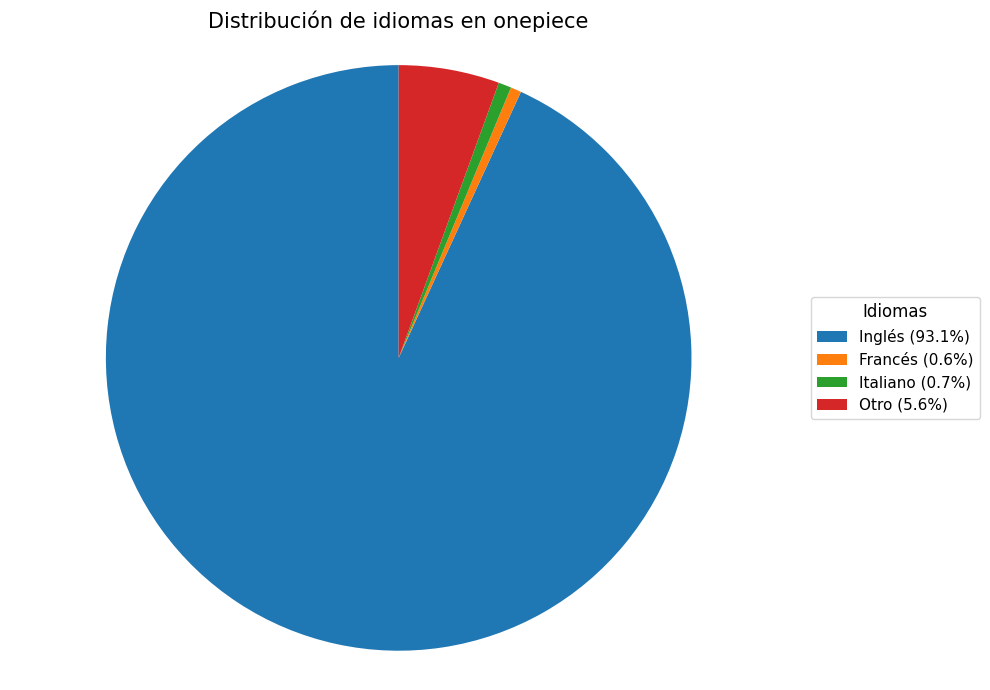

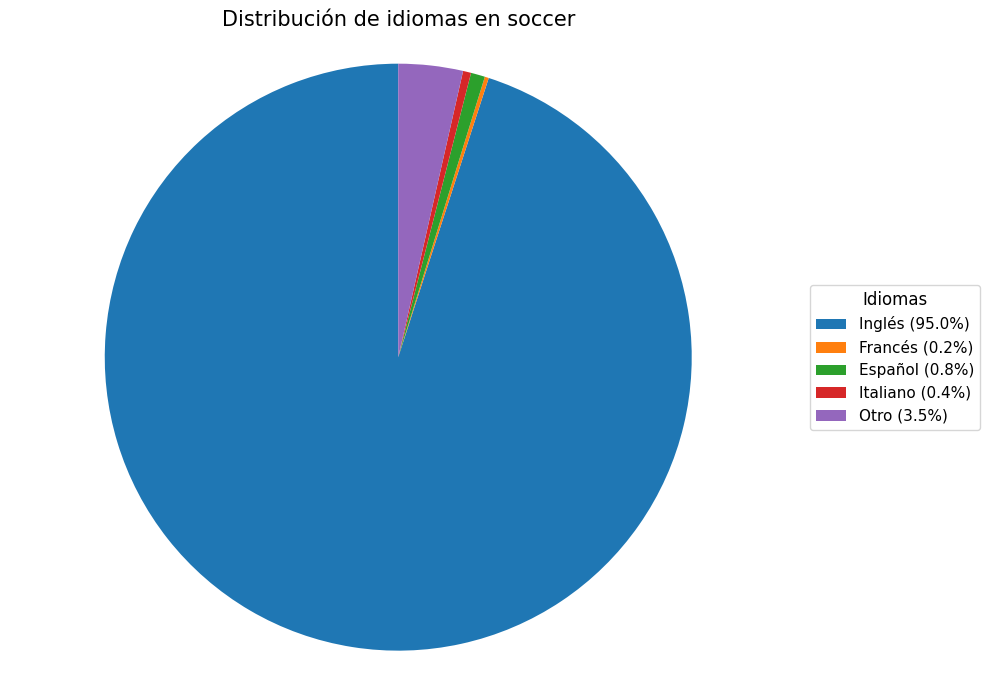

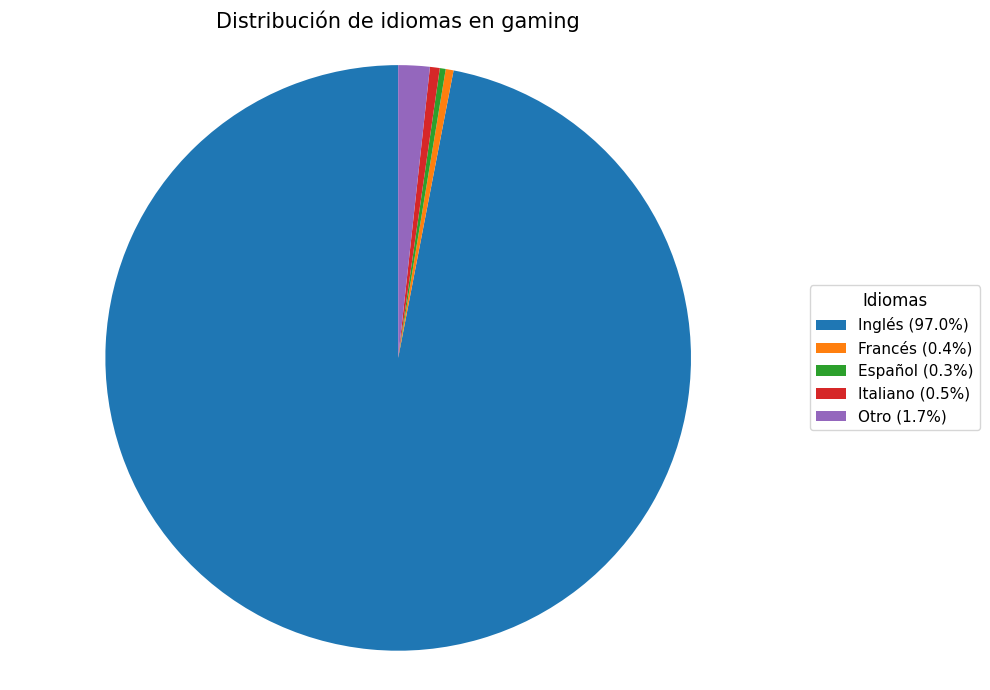

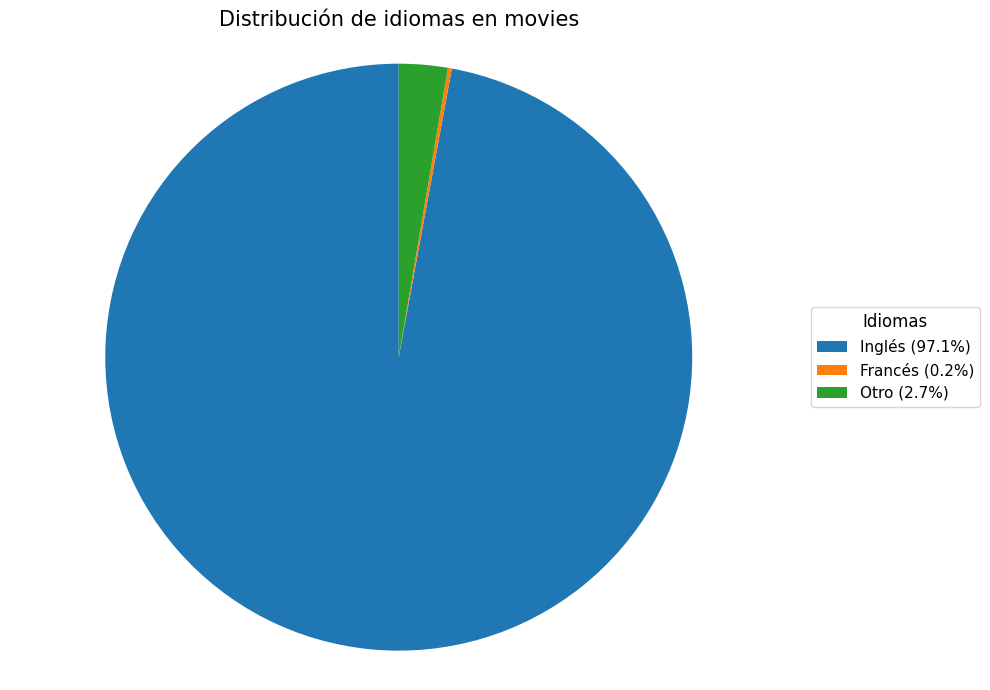

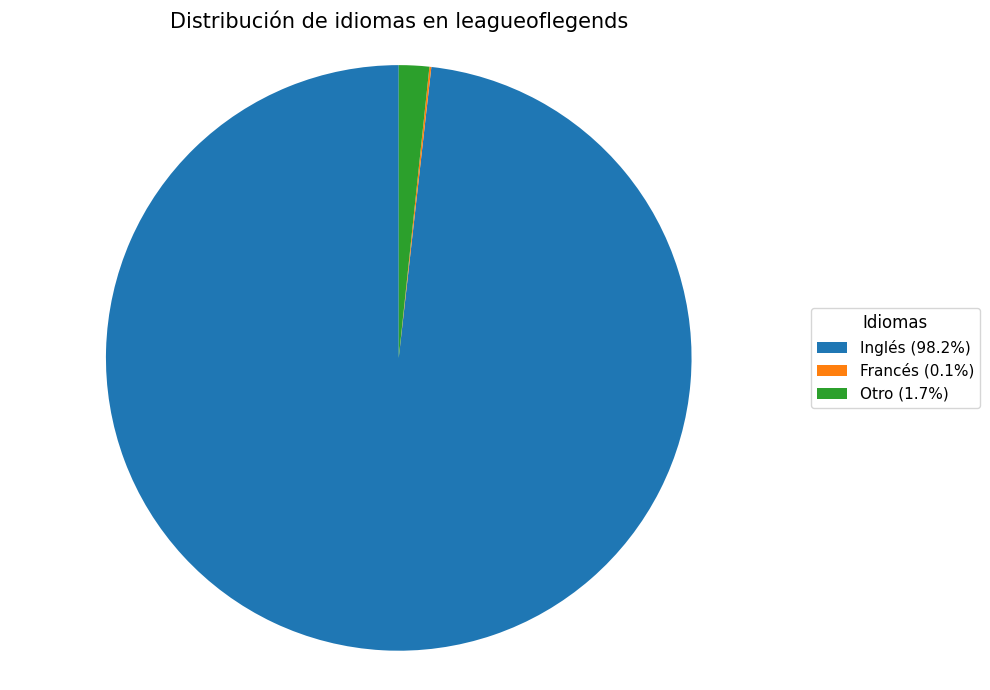

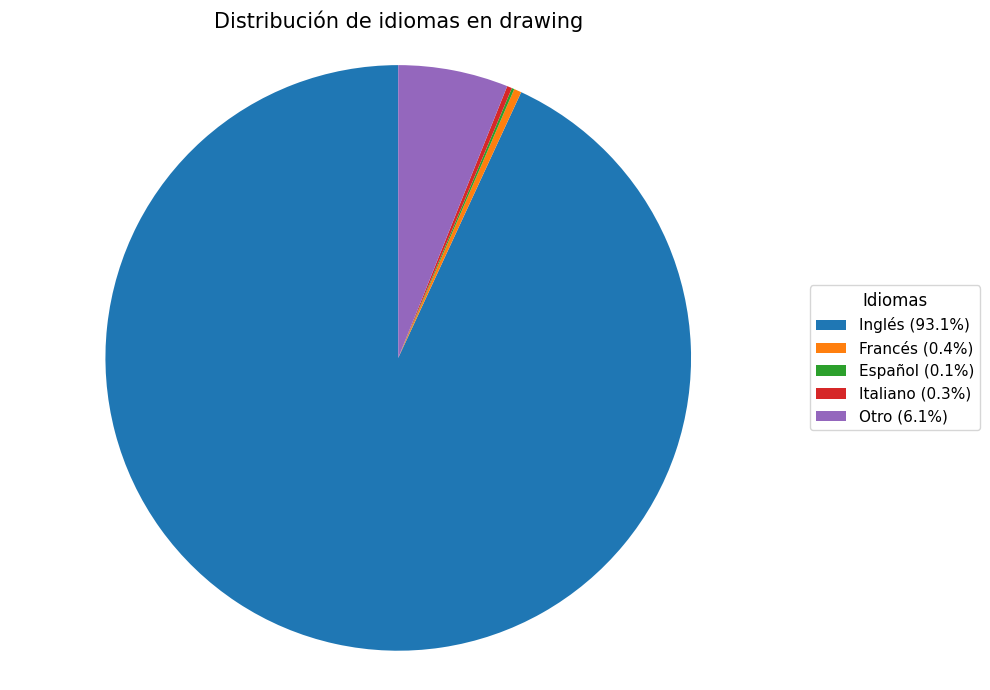

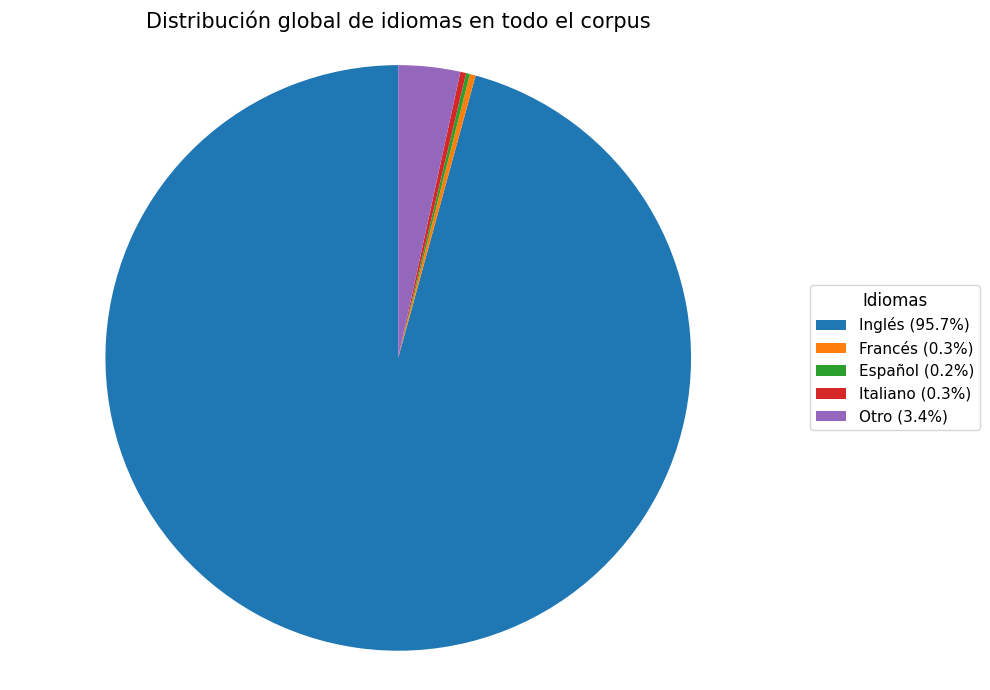

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Idiomas que queremos mostrar por separado
idiomas_principales = ["en", "fr", "es", "it"]

# Diccionario para poner nombres bonitos en la leyenda
nombres_idiomas = {
    "en": "Inglés",
    "fr": "Francés",
    "es": "Español",
    "it": "Italiano",
    "otro": "Otro"
}

def agrupar_idiomas_principales(df_idiomas):
    df = df_idiomas.copy()

    df["idioma_agrupado"] = df["idioma"].apply(
        lambda x: x if x in idiomas_principales else "otro"
    )

    df_agrupado = df.groupby("idioma_agrupado", as_index=False)["frecuencia"].sum()

    total = df_agrupado["frecuencia"].sum()
    df_agrupado["porcentaje"] = df_agrupado["frecuencia"] / total * 100

    orden = ["en", "fr", "es", "it", "otro"]
    df_agrupado["orden"] = df_agrupado["idioma_agrupado"].apply(lambda x: orden.index(x))
    df_agrupado = df_agrupado.sort_values("orden").drop(columns="orden")

    return df_agrupado

# -----------------------------------
# PIE CHART POR SUBREDDIT
# -----------------------------------
for subreddit in subreddits:
    idiomas_file = f"idiomas/{subreddit}_idiomas.csv"

    if not os.path.exists(idiomas_file):
        print(f"No existe {idiomas_file}, se salta.")
        continue

    df_idiomas = pd.read_csv(idiomas_file)
    df_plot = agrupar_idiomas_principales(df_idiomas)

    # Crear etiquetas con nombre + porcentaje
    etiquetas = [
        f"{nombres_idiomas[i]} ({p:.1f}%)"
        for i, p in zip(df_plot["idioma_agrupado"], df_plot["porcentaje"])
    ]

    plt.figure(figsize=(10, 7))

    wedges, texts = plt.pie(
        df_plot["frecuencia"],
        startangle=90
    )

    plt.legend(
        wedges,
        etiquetas,
        title="Idiomas",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=11,
        title_fontsize=12
    )

    plt.title(f"Distribución de idiomas en {subreddit}", fontsize=15)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

# -----------------------------------
# PIE CHART GLOBAL
# -----------------------------------
df_plot_global = agrupar_idiomas_principales(df_idiomas_global)

# Etiquetas globales con porcentaje
etiquetas_global = [
    f"{nombres_idiomas[i]} ({p:.1f}%)"
    for i, p in zip(df_plot_global["idioma_agrupado"], df_plot_global["porcentaje"])
]

plt.figure(figsize=(10, 7))

wedges, texts = plt.pie(
    df_plot_global["frecuencia"],
    startangle=90
)

plt.legend(
    wedges,
    etiquetas_global,
    title="Idiomas",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=11,
    title_fontsize=12
)

plt.title("Distribución global de idiomas en todo el corpus", fontsize=15)
plt.axis("equal")
plt.tight_layout()
plt.show()